In [1]:
# !pip install ta
# !pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as ans
from ta.momentum import RSIIndicator
from sklearn.model_selection import train_test_split

# 1. Data Collection

In [3]:
# initializing stock variable
ticker = "GOOG"

# getting and displaying the data of 11 years of GOOG's stock history
data = yf.download(ticker, start="2014-01-01", end="2025-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2014-01-02,27.517696,27.632156,27.397551,27.575545,73129082
2014-01-03,27.316959,27.611884,27.315229,27.564173,66917888
2014-01-06,27.621525,27.659594,27.352557,27.514976,71037271
2014-01-07,28.154020,28.174540,27.716457,27.811385,102486711
2014-01-08,28.212608,28.363161,28.016321,28.330529,90036218


In [4]:
data.columns

MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

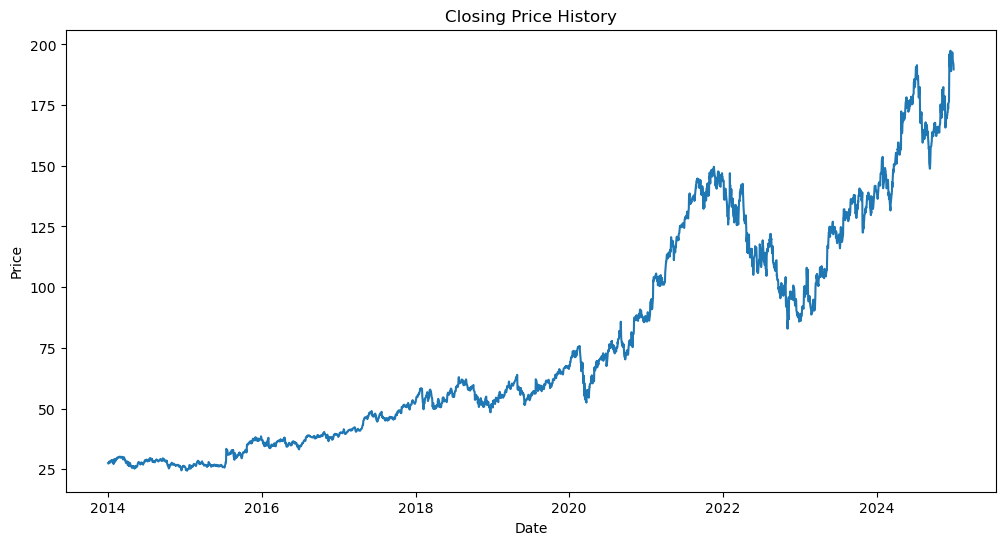

In [5]:
# display the closing price history
plt.figure(figsize=(12,6))

plt.plot(data["Close"])

plt.title("Closing Price History")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

# 2. Feature Engineering

In [6]:
# change in close price each day
data["Price_Change"] = data["Close"].diff()

# 20 day moving avg
data["SMA20"] = data["Close"].rolling(window=20).mean()

# 50 day moving avg
data["SMA50"] = data["Close"].rolling(window=50).mean()

# pct change between rows, today and yesterday
data["Daily_Return"] = data["Close"].pct_change()

# standard deviation of last 20 days, higher value = greater volatility
data["Volatility_20"] = data["Daily_Return"].rolling(window=20).std()

# yesterday's price to help predict tomorrow's price
data["Lag1_Close"] = data["Close"].shift(1)

# RSI > 70: overbought
# RSI < 30: oversold
rsi = RSIIndicator(close=data["Close"].squeeze(), window=14)

data["RSI_14"] = rsi.rsi()

# 3. Prediction Targets

In [7]:
# Define target: shift Close price to align today's data with tomorrow's outcome
data["Tomorrow_Close"] = data["Close"].shift(-1)

# Tomorrow > Today: 1 (price went UP)
# Tomorrow <= Today: 0 (price went DOWN)
data["Direction"] = (data["Tomorrow_Close"] > data["Close"].squeeze()).astype(int)

In [8]:
# removing null values, rows contain null values because:
# SMA20 needs 20 days
# SMA50 needs 50 days
# RSI needs 14 days
data = data.dropna()

In [9]:
data.head(10)

Price,Close,High,Low,Open,Volume,Price_Change,SMA20,SMA50,Daily_Return,Volatility_20,Lag1_Close,RSI_14,Tomorrow_Close,Direction
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
Date,,,,,,,,,,,,,,
2014-03-14,28.993061,29.439774,28.986386,29.220249,92099924,-0.401964,29.866263,28.937783,-0.013675,0.007145,29.395025,41.274404,29.470179,1
2014-03-17,29.470179,29.593044,29.124329,29.152512,86808163,0.477118,29.853037,28.976832,0.016456,0.008132,28.993061,49.471716,29.943834,1
2014-03-18,29.943834,29.950510,29.493908,29.533710,72872123,0.473656,29.853507,29.029370,0.016072,0.008805,29.470179,56.033054,29.646936,0
2014-03-19,29.646936,29.961885,29.527284,29.957188,64757822,-0.296898,29.849687,29.069878,-0.009915,0.008948,29.943834,51.517207,29.595268,0
2014-03-20,29.595268,29.903047,29.550770,29.664239,67640587,-0.051668,29.841097,29.098703,-0.001743,0.008948,29.646936,50.750663,29.246202,0
2014-03-21,29.246202,29.903542,29.231618,29.821466,128821050,-0.349066,29.815448,29.119375,-0.011795,0.009313,29.595268,45.793248,28.625452,0
2014-03-24,28.625452,29.292183,28.329290,29.274632,121939352,-0.620750,29.747984,29.133065,-0.021225,0.010152,29.246202,38.576650,28.644983,1
2014-03-25,28.644983,28.919884,28.355252,28.824956,96769361,0.019531,29.672238,29.147176,0.000682,0.009985,28.625452,38.902899,27.983692,0


In [10]:
data.describe()

Price,Close,High,Low,Open,Volume,Price_Change,SMA20,SMA50,Daily_Return,Volatility_20,Lag1_Close,RSI_14,Tomorrow_Close,Direction
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,,,,,
count,2718.000000,2718.000000,2718.000000,2718.000000,2.718000e+03,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000
mean,78.071378,78.858382,77.256433,78.026813,3.147159e+07,0.059804,77.505034,76.686182,0.000846,0.016183,78.011574,54.056045,78.130506,0.536424
std,44.897072,45.383439,44.417028,44.868964,1.628444e+07,1.645131,44.389548,43.797690,0.017650,0.007249,44.853574,11.362595,44.938218,0.498763
min,24.377235,24.546795,24.130270,24.481170,1.584340e+05,-13.349884,25.340448,25.765435,-0.111008,0.002915,24.377235,24.077319,24.377235,0.000000
25%,38.963520,39.194783,38.731630,38.895899,2.145550e+07,-0.419726,38.670998,38.612246,-0.007243,0.010847,38.952849,45.776771,38.981009,0.000000
50%,59.863266,60.360285,59.406314,59.801972,2.745900e+07,0.058308,59.630921,59.377033,0.001063,0.014719,59.849119,54.137802,59.891802,1.000000
75%,116.074425,117.370955,114.348120,115.810770,3.630150e+07,0.619219,115.024176,113.553736,0.009440,0.019972,116.022320,62.441641,116.126898,1.000000
max,197.391541,202.093233,195.927235,197.760096,2.232980e+08,15.622849,187.406953,179.180170,0.160524,0.055626,197.391541,89.071326,197.391541,1.000000


In [11]:
data.columns

MultiIndex([(         'Close', 'GOOG'),
            (          'High', 'GOOG'),
            (           'Low', 'GOOG'),
            (          'Open', 'GOOG'),
            (        'Volume', 'GOOG'),
            (  'Price_Change',     ''),
            (         'SMA20',     ''),
            (         'SMA50',     ''),
            (  'Daily_Return',     ''),
            ( 'Volatility_20',     ''),
            (    'Lag1_Close',     ''),
            (        'RSI_14',     ''),
            ('Tomorrow_Close',     ''),
            (     'Direction',     '')],
           names=['Price', 'Ticker'])

# 4. Feature and Target variable Creation

In [12]:
# predictor variables used by the models
features = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "Price_Change",
    "SMA20",
    "SMA50",
    "Daily_Return",
    "Volatility_20",
    "Lag1_Close",
    "RSI_14"
]

# feature matrix
X = data[features]

# Target variable for price prediction(regression)
y_price = data["Tomorrow_Close"]

# Target variable for price direction prediction(classification)
y_direction = data["Direction"]

# 5. Splitting data for training and testing

In [21]:
# Splitting data for price
# shuffle off(time series data) so it doesn't train on new data and test on old, 
# Training size: 80%, Testing size: 20%
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X,
    y_price,
    test_size = 0.2,
    shuffle = False
)
X_train_price.shape, X_test_price.shape, y_train_price.shape, y_test_price.shape

((2174, 12), (544, 12), (2174,), (544,))

In [22]:
# Splitting data for direction following the same rules as above
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X,
    y_direction,
    test_size = 0.2,
    shuffle = False
)
X_train_dir.shape, X_test_dir.shape, y_train_dir.shape, y_test_dir.shape

((2174, 12), (544, 12), (2174,), (544,))